# Color-Invariant Saree Design Recognition
Metric-learning retrieval and verification with a DINOv2 backbone. Sections: 1 Setup, 2 Configuration, 3 Data upload, 4 Data inventory, 5 Preprocessing and Kaggle de-duplication, 6 Model definition, 7 DeepLure design labels, 8 Group-aware splits, 9 Augmentation, 10 Datasets and samplers, 11 Loss, 12 Training, 13 Evaluation, 14 Experiments, 15 Analysis, 16 Inference, 17 Efficiency, 18 Export.

In [1]:
import os, sys, re, json, math, time, glob, random, shutil, zipfile, subprocess, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Dict, Optional, Tuple

try:
    import transformers
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])

import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageOps, ImageDraw
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T2
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from transformers import AutoModel

warnings.filterwarnings("ignore")
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except Exception:
    colab_files = None
    IN_COLAB = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = DEVICE == "cuda"
print("device:", DEVICE, "| torch:", torch.__version__, "| colab:", IN_COLAB)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

device: cuda | torch: 2.11.0+cu130 | colab: True
gpu: Tesla T4


## 2. Configuration

In [2]:
@dataclass
class Cfg:
    work_dir: str = "/content/saree_work" if IN_COLAB else "./saree_work"
    search_dirs: Tuple[str, ...] = ("/content", ".")
    backbone: str = "facebook/dinov2-small"
    img_size: int = 224
    store_size: int = 256
    emb_dim: int = 256
    head_hidden: int = 1024
    head_dropout: float = 0.1
    unfreeze_blocks: int = 4
    stage0_epochs: int = 8
    stage1_epochs: int = 30
    steps_per_epoch: int = 12
    patience: int = 8
    lr_head_stage0: float = 1e-3
    lr_head_stage1: float = 3e-4
    lr_backbone: float = 1e-5
    weight_decay: float = 0.05
    warmup_frac: float = 0.1
    grad_clip: float = 1.0
    temperature: float = 0.1
    designs_per_batch: int = 8
    images_per_design: int = 4
    kaggle_per_batch: int = 16
    hard_color_designs: int = 3
    fn_guard_quantile: float = 0.995
    phash_thr: int = 6
    blank_lap_var: float = 35.0
    low_texture_lap_var: float = 60.0
    cluster_nn_quantile: float = 0.55
    split_nn_quantile: float = 0.80
    colorway_delta_e: float = 18.0
    use_verified_csv: bool = False
    verified_csv_name: str = "designs_verified.csv"
    val_frac: float = 0.2
    test_frac: float = 0.2
    kaggle_val_frac: float = 0.15
    kaggle_test_frac: float = 0.15
    aux_category_weight: float = 0.0
    num_workers: int = 2
    seed: int = 42
    eval_bs: int = 64
    bootstrap: int = 1000
    save_image_grids: bool = True

CFG = Cfg()
WORK = Path(CFG.work_dir)
for sub in ("raw", "review", "figures", "out"):
    (WORK / sub).mkdir(parents=True, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)
print(json.dumps(asdict(CFG), indent=1))

{
 "work_dir": "/content/saree_work",
 "search_dirs": [
  "/content",
  "."
 ],
 "backbone": "facebook/dinov2-small",
 "img_size": 224,
 "store_size": 256,
 "emb_dim": 256,
 "head_hidden": 1024,
 "head_dropout": 0.1,
 "unfreeze_blocks": 4,
 "stage0_epochs": 8,
 "stage1_epochs": 30,
 "steps_per_epoch": 12,
 "patience": 8,
 "lr_head_stage0": 0.001,
 "lr_head_stage1": 0.0003,
 "lr_backbone": 1e-05,
 "weight_decay": 0.05,
 "warmup_frac": 0.1,
 "grad_clip": 1.0,
 "temperature": 0.1,
 "designs_per_batch": 8,
 "images_per_design": 4,
 "kaggle_per_batch": 16,
 "hard_color_designs": 3,
 "fn_guard_quantile": 0.995,
 "phash_thr": 6,
 "blank_lap_var": 35.0,
 "low_texture_lap_var": 60.0,
 "cluster_nn_quantile": 0.55,
 "split_nn_quantile": 0.8,
 "colorway_delta_e": 18.0,
 "use_verified_csv": false,
 "verified_csv_name": "designs_verified.csv",
 "val_frac": 0.2,
 "test_frac": 0.2,
 "kaggle_val_frac": 0.15,
 "kaggle_test_frac": 0.15,
 "aux_category_weight": 0.0,
 "num_workers": 2,
 "seed": 42,
 "eval_

## 3. Data upload and extraction

In [3]:
def zip_kind(path: str) -> Optional[str]:
    with zipfile.ZipFile(path) as z:
        names = z.namelist()
    if any(n.startswith("handloom_sarees/") or "/handloom_sarees/" in n for n in names):
        return "deeplure"
    if any(re.match(r"^(train|valid|test)/", n) for n in names):
        return "kaggle"
    return None

def scan_zips() -> Dict[str, str]:
    found = {}
    for d in CFG.search_dirs:
        for p in sorted(glob.glob(os.path.join(d, "*.zip"))):
            try:
                k = zip_kind(p)
            except Exception:
                continue
            if k and k not in found:
                found[k] = p
    return found

found = scan_zips()
if len(found) < 2 and IN_COLAB:
    print("Select the DeepLure zip and the Kaggle zip")
    colab_files.upload()
    found = scan_zips()
assert {"deeplure", "kaggle"} <= set(found), f"missing datasets, found: {found}"

for kind, zp in found.items():
    dst = WORK / "raw" / kind
    if not dst.exists() or not any(dst.rglob("*.jpg")):
        dst.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zp) as z:
            z.extractall(dst)
    print(kind, "->", zp)

IMG_EXT = (".jpg", ".jpeg", ".png", ".webp")
DL_FILES = sorted(p for p in (WORK / "raw" / "deeplure").rglob("*") if p.suffix.lower() in IMG_EXT)
KG_FILES = sorted(p for p in (WORK / "raw" / "kaggle").rglob("*") if p.suffix.lower() in IMG_EXT)
print("deeplure images:", len(DL_FILES), "| kaggle images:", len(KG_FILES))

Select the DeepLure zip and the Kaggle zip


Saving archive.zip to archive.zip
Saving handloom_sarees-20261005T071046Z-1-001.zip to handloom_sarees-20261005T071046Z-1-001.zip
kaggle -> /content/archive.zip
deeplure -> /content/handloom_sarees-20261005T071046Z-1-001.zip
deeplure images: 165 | kaggle images: 1468


## 4. Data inventory

In [4]:
def kaggle_split_and_class(p: Path):
    rel = p.relative_to(WORK / "raw" / "kaggle").parts
    return rel[0], rel[1] if len(rel) > 2 else "unknown"

kg_inv = pd.DataFrame([dict(split=kaggle_split_and_class(p)[0], category=kaggle_split_and_class(p)[1]) for p in KG_FILES])
print("Kaggle original split x category (leaky split, shown for reference only)")
print(kg_inv.groupby(["split", "category"]).size().unstack(fill_value=0))

def size_of(p):
    with Image.open(p) as im:
        return im.size

dl_sizes = pd.DataFrame([size_of(p) for p in DL_FILES], columns=["w", "h"])
print("\nDeepLure size summary")
print(dl_sizes.describe().round(0))
print("non-square DeepLure images:", int(((dl_sizes.w - dl_sizes.h).abs() > 5).sum()))

Kaggle original split x category (leaky split, shown for reference only)
category  Banarasi  Bandhani  Ikat  Pichwai
split                                      
test            14        15    13       18
train          432       279   303      279
valid           43        22    26       24

DeepLure size summary
            w       h
count   165.0   165.0
mean    815.0   821.0
std     329.0   328.0
min     226.0   226.0
25%     590.0   589.0
50%     662.0   662.0
75%     986.0   986.0
max    1512.0  1512.0
non-square DeepLure images: 5


## 5. Preprocessing, perceptual hashing and Kaggle de-duplication

In [5]:
def load_rgb(path: Path, size: int) -> np.ndarray:
    with Image.open(path) as im:
        im = ImageOps.exif_transpose(im).convert("RGB").resize((size, size), Image.BICUBIC)
        return np.asarray(im, dtype=np.uint8)

def load_many(paths: List[Path], size: int) -> np.ndarray:
    return np.stack([load_rgb(p, size) for p in paths])

def phash_bits(imgs: np.ndarray) -> np.ndarray:
    out = []
    for im in imgs:
        g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
        g = cv2.resize(g, (32, 32), interpolation=cv2.INTER_AREA).astype(np.float32)
        d = cv2.dct(g)[:8, :8].flatten()
        out.append(d > np.median(d[1:]))
    return np.stack(out)

def hamming(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a.astype(np.float32); b = b.astype(np.float32)
    return (a.shape[1] - (a @ b.T + (1 - a) @ (1 - b).T)).round().astype(np.int16)

def union_find_groups(n: int, pairs: np.ndarray) -> np.ndarray:
    parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    for i, j in pairs:
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj
    roots = np.array([find(i) for i in range(n)])
    _, lab = np.unique(roots, return_inverse=True)
    return lab

t0 = time.time()
DL_IMGS = load_many(DL_FILES, CFG.store_size)
KG_ALL = load_many(KG_FILES, CFG.store_size)
DL_PH = phash_bits(DL_IMGS)
KG_PH = phash_bits(KG_ALL)
print(f"loaded {len(DL_IMGS)} + {len(KG_ALL)} images in {time.time()-t0:.0f}s")

kg_d = hamming(KG_PH, KG_PH)
kg_pairs = np.argwhere(np.triu(kg_d <= CFG.phash_thr, 1))
kg_group = union_find_groups(len(KG_ALL), kg_pairs)
kg_gray = np.stack([cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) for im in KG_ALL])
kg_noise = ((kg_gray <= 2) | (kg_gray >= 253)).reshape(len(KG_ALL), -1).mean(1)
kg_split_orig = np.array([kaggle_split_and_class(p)[0] for p in KG_FILES])
kg_cat = np.array([kaggle_split_and_class(p)[1] for p in KG_FILES])

reps = []
for g in np.unique(kg_group):
    members = np.where(kg_group == g)[0]
    reps.append(members[np.argmin(kg_noise[members])])
reps = np.array(sorted(reps))
orig_groups = pd.Series(kg_group)
cross_split = pd.DataFrame(dict(g=kg_group, s=kg_split_orig)).groupby("g").s.nunique()
print(f"Kaggle: {len(KG_ALL)} raw -> {len(reps)} unique sources after pHash grouping (hamming <= {CFG.phash_thr})")
print("source groups spanning more than one original split:", int((cross_split > 1).sum()), "of", len(cross_split))
print("group size distribution:", orig_groups.value_counts().value_counts().sort_index().to_dict())

loaded 165 + 1468 images in 14s
Kaggle: 1468 raw -> 410 unique sources after pHash grouping (hamming <= 6)
source groups spanning more than one original split: 88 of 410
group size distribution: {1: 64, 2: 15, 3: 150, 4: 81, 6: 100}


In [6]:
def gray_stats(imgs: np.ndarray):
    g = np.stack([cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) for im in imgs])
    lap = np.array([cv2.Laplacian(x, cv2.CV_64F).var() for x in g])
    return lap, g.reshape(len(g), -1).std(1)

def hsv_hist(imgs: np.ndarray) -> np.ndarray:
    out = []
    for im in imgs:
        hsv = cv2.cvtColor(im, cv2.COLOR_RGB2HSV)
        h = cv2.calcHist([hsv], [0, 1, 2], None, [8, 4, 4], [0, 180, 0, 256, 0, 256]).ravel()
        out.append(h / h.sum())
    return np.stack(out).astype(np.float32)

def mean_lab(imgs: np.ndarray) -> np.ndarray:
    return np.stack([cv2.cvtColor(im, cv2.COLOR_RGB2LAB).reshape(-1, 3).mean(0) for im in imgs]).astype(np.float32)

IMGS = np.concatenate([DL_IMGS, KG_ALL[reps]])
PH = np.concatenate([DL_PH, KG_PH[reps]])
LAP, GSTD = gray_stats(IMGS)
COLSIG = hsv_hist(IMGS)
LAB = mean_lab(IMGS)
PHD = hamming(PH, PH)

rows = []
for i, p in enumerate(DL_FILES):
    rows.append(dict(uid=i, path=str(p), name=p.name, source="deeplure", category="", kaggle_group=-1))
for k, r in enumerate(reps):
    rows.append(dict(uid=len(DL_FILES) + k, path=str(KG_FILES[r]), name=KG_FILES[r].name, source="kaggle",
                     category=kg_cat[r], kaggle_group=int(kg_group[r])))
META = pd.DataFrame(rows)
META["lap_var"] = LAP
META["usable"] = LAP >= CFG.blank_lap_var
META["low_texture"] = LAP < CFG.low_texture_lap_var
SAT = np.array([cv2.cvtColor(im, cv2.COLOR_RGB2HSV)[..., 1].mean() for im in IMGS])
META["low_saturation"] = SAT < 40
dlm = META.source == "deeplure"
print(f"DeepLure: {int(dlm.sum())} images | blank (lap var < {CFG.blank_lap_var}): {int((dlm & ~META.usable).sum())} | "
      f"low texture (< {CFG.low_texture_lap_var}): {int((dlm & META.low_texture).sum())} | low-saturation (mean S < 40): {int((dlm & META.low_saturation).sum())}")
print("Kaggle representatives:", int((META.source == 'kaggle').sum()), "| blank:", int(((META.source == 'kaggle') & ~META.usable).sum()))

DeepLure: 165 images | blank (lap var < 35.0): 5 | low texture (< 60.0): 14 | low-saturation (mean S < 40): 78
Kaggle representatives: 410 | blank: 0


## 6. Model definition and shared preprocessing

In [7]:
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
LUMA = torch.tensor([0.299, 0.587, 0.114]).view(1, 3, 1, 1)

def normalize(x: torch.Tensor) -> torch.Tensor:
    return (x - MEAN.to(x.device)) / STD.to(x.device)

def to_gray3(x: torch.Tensor) -> torch.Tensor:
    return (x * LUMA.to(x.device)).sum(1, keepdim=True).expand(-1, 3, -1, -1)

def prep_uint8(batch: np.ndarray, gray: bool = False) -> torch.Tensor:
    x = torch.from_numpy(batch).permute(0, 3, 1, 2).float().div(255.0).to(DEVICE)
    x = F.interpolate(x, size=(CFG.img_size, CFG.img_size), mode="bilinear", antialias=True, align_corners=False)
    if gray:
        x = to_gray3(x)
    return normalize(x)

def load_backbone() -> nn.Module:
    return AutoModel.from_pretrained(CFG.backbone)

def pool_tokens(h: torch.Tensor) -> torch.Tensor:
    return torch.cat([h[:, 0], h[:, 1:].mean(1)], dim=1)

class SareeEmbedder(nn.Module):
    def __init__(self, backbone: nn.Module, emb_dim: int, hidden: int, dropout: float, n_cat: int = 4):
        super().__init__()
        self.backbone = backbone
        d = backbone.config.hidden_size * 2
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, hidden), nn.GELU(), nn.Linear(hidden, emb_dim))
        self.cat_head = nn.Linear(emb_dim, n_cat)
        self.backbone_trainable = False

    def features(self, x: torch.Tensor) -> torch.Tensor:
        if self.backbone_trainable:
            h = self.backbone(pixel_values=x).last_hidden_state
        else:
            with torch.no_grad():
                h = self.backbone(pixel_values=x).last_hidden_state
        return pool_tokens(h)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.head(self.features(x)).float(), dim=-1)

    def set_stage(self, stage: int, unfreeze_blocks: int):
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone_trainable = stage >= 1
        if stage >= 1:
            for blk in self.backbone.encoder.layer[-unfreeze_blocks:]:
                for p in blk.parameters():
                    p.requires_grad = True
            for p in self.backbone.layernorm.parameters():
                p.requires_grad = True

def build_model() -> SareeEmbedder:
    return SareeEmbedder(load_backbone(), CFG.emb_dim, CFG.head_hidden, CFG.head_dropout).to(DEVICE)

class FrozenBaseline(nn.Module):
    def __init__(self, backbone: nn.Module):
        super().__init__()
        self.backbone = backbone.to(DEVICE).eval()
    @torch.no_grad()
    def forward(self, x):
        return F.normalize(pool_tokens(self.backbone(pixel_values=x).last_hidden_state).float(), dim=-1)

@torch.no_grad()
def embed_images(fn: nn.Module, imgs: np.ndarray, gray: bool = False) -> np.ndarray:
    was_training = fn.training
    fn.eval()
    out = []
    for i in range(0, len(imgs), CFG.eval_bs):
        x = prep_uint8(imgs[i:i + CFG.eval_bs], gray)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            z = fn(x)
        out.append(z.float().cpu())
    fn.train(was_training)
    return torch.cat(out).numpy()

@torch.no_grad()
def raw_backbone_features(gray: bool = True) -> np.ndarray:
    bb = load_backbone().to(DEVICE).eval()
    out = []
    for i in range(0, len(IMGS), CFG.eval_bs):
        x = prep_uint8(IMGS[i:i + CFG.eval_bs], gray)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            f = pool_tokens(bb(pixel_values=x).last_hidden_state)
        out.append(F.normalize(f.float(), dim=-1).cpu())
    del bb
    return torch.cat(out).numpy()

## 7. DeepLure design labels (proposed clusters and optional verified CSV)

In [8]:
def hog_descriptor(img: np.ndarray) -> np.ndarray:
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    g = cv2.resize(g, (128, 128), interpolation=cv2.INTER_AREA)
    g = cv2.createCLAHE(2.0, (4, 4)).apply(g)
    g = cv2.GaussianBlur(g, (3, 3), 0)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0); gy = cv2.Sobel(g, cv2.CV_32F, 0, 1)
    mag = np.hypot(gx, gy); ang = np.arctan2(gy, gx) % np.pi
    feats = []
    for i in range(0, 128, 16):
        for j in range(0, 128, 16):
            h, _ = np.histogram(ang[i:i + 16, j:j + 16].ravel(), 9, (0, np.pi), weights=mag[i:i + 16, j:j + 16].ravel())
            feats.append(h)
    f = np.concatenate(feats)
    return f / (np.linalg.norm(f) + 1e-6)

DINO_GRAY = raw_backbone_features(gray=True)
HOG = np.stack([hog_descriptor(im) for im in IMGS])
PROPOSAL_FEATS = np.concatenate([0.5 * DINO_GRAY, 0.5 * HOG], axis=1)
PROPOSAL_FEATS /= np.linalg.norm(PROPOSAL_FEATS, axis=1, keepdims=True)

dl_idx = META.index[(META.source == "deeplure") & META.usable].to_numpy()
Xd = PROPOSAL_FEATS[dl_idx]
cosd = 1 - Xd @ Xd.T
np.fill_diagonal(cosd, np.inf)
nn_dist = cosd.min(1)
thr_design = float(np.quantile(nn_dist, CFG.cluster_nn_quantile))
thr_split = float(np.quantile(nn_dist, CFG.split_nn_quantile))

def agglo(X: np.ndarray, thr: float) -> np.ndarray:
    return AgglomerativeClustering(n_clusters=None, distance_threshold=thr, metric="cosine", linkage="average").fit(X).labels_

design_lab = agglo(Xd, thr_design)
split_lab = agglo(Xd, thr_split)
sizes = np.bincount(design_lab)
print(f"proposal threshold {thr_design:.3f} -> {len(sizes)} proposed designs | singletons {(sizes == 1).sum()} | size histogram {np.bincount(sizes).tolist()}")
print(f"split-group threshold {thr_split:.3f} -> {split_lab.max() + 1} groups")

META["design_id"] = ""
META["split_group"] = ""
META["colorway_id"] = ""
META["label_source"] = ""
META.loc[dl_idx, "design_id"] = [f"auto_design_{l:03d}" for l in design_lab]
META.loc[dl_idx, "split_group"] = [f"auto_group_{l:03d}" for l in split_lab]
META.loc[dl_idx, "label_source"] = "auto_proposed"
bad_idx = META.index[(META.source == "deeplure") & ~META.usable].to_numpy()
META.loc[bad_idx, ["design_id", "split_group", "label_source"]] = ["blank", "blank", "excluded"]
kg_idx = META.index[META.source == "kaggle"].to_numpy()
META.loc[kg_idx, "design_id"] = [f"kaggle_{g}" for g in META.loc[kg_idx, "kaggle_group"]]
META.loc[kg_idx, "split_group"] = META.loc[kg_idx, "design_id"]
META.loc[kg_idx, "label_source"] = "kaggle_unique_source"

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

proposal threshold 0.269 -> 106 proposed designs | singletons 76 | size histogram [0, 76, 20, 2, 3, 4, 1]
split-group threshold 0.324 -> 74 groups


LABEL SOURCE: AUTO-PROPOSED PSEUDO-LABELS (provisional; clusters come from the same frozen features that the baselines use)
review sheets: 5 | proposed CSV: /content/saree_work/out/proposed_designs.csv


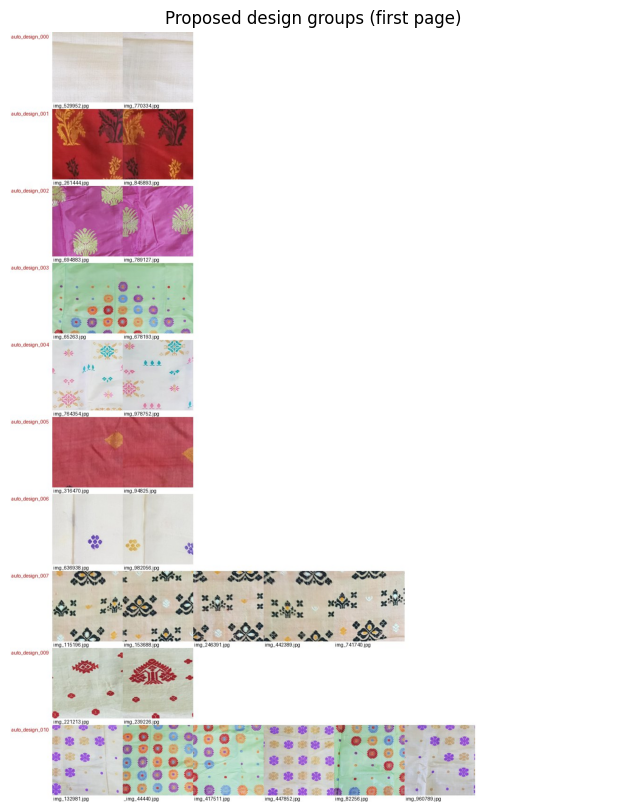

In [9]:
def assign_colorways(meta: pd.DataFrame):
    for d, g in meta[(meta.source == "deeplure") & meta.usable].groupby("design_id"):
        idx = g.index.to_numpy()
        if len(idx) == 1:
            meta.loc[idx, "colorway_id"] = f"{d}_cw0"
            continue
        lab = AgglomerativeClustering(n_clusters=None, distance_threshold=CFG.colorway_delta_e, linkage="average").fit(LAB[idx]).labels_
        meta.loc[idx, "colorway_id"] = [f"{d}_cw{l}" for l in lab]

def load_verified_csv(meta: pd.DataFrame) -> pd.DataFrame:
    path = None
    for d in CFG.search_dirs:
        cand = os.path.join(d, CFG.verified_csv_name)
        if os.path.exists(cand):
            path = cand
    if path is None and IN_COLAB:
        print("Select the verified designs CSV")
        colab_files.upload()
        for d in CFG.search_dirs:
            cand = os.path.join(d, CFG.verified_csv_name)
            if os.path.exists(cand):
                path = cand
    if path is None:
        raise FileNotFoundError(CFG.verified_csv_name)
    v = pd.read_csv(path)
    v["image_path"] = v["image_path"].astype(str).map(lambda s: os.path.basename(s))
    need = {"image_path", "design_id"}
    assert need <= set(v.columns), f"CSV needs columns {need}"
    v = v.drop_duplicates("image_path").set_index("image_path")
    mask = (meta.source == "deeplure") & meta.usable
    covered = meta.loc[mask, "name"].isin(v.index)
    print(f"verified CSV covers {int(covered.sum())} of {int(mask.sum())} usable DeepLure images")
    for i in meta.index[mask]:
        nm = meta.at[i, "name"]
        if nm in v.index:
            meta.at[i, "design_id"] = str(v.at[nm, "design_id"])
            meta.at[i, "split_group"] = str(v.at[nm, "split_group"]) if "split_group" in v.columns and pd.notna(v.at[nm, "split_group"]) else str(v.at[nm, "design_id"])
            meta.at[i, "colorway_id"] = str(v.at[nm, "colorway_id"]) if "colorway_id" in v.columns and pd.notna(v.at[nm, "colorway_id"]) else ""
            meta.at[i, "label_source"] = "manual_verified"
        else:
            meta.at[i, "design_id"] = f"unlabeled_{nm}"
            meta.at[i, "split_group"] = f"unlabeled_{nm}"
            meta.at[i, "label_source"] = "manual_missing"
    return meta

if CFG.use_verified_csv:
    META = load_verified_csv(META)
assign_colorways(META)
if CFG.use_verified_csv:
    fill = (META.source == "deeplure") & META.usable & (META.colorway_id.astype(str).str.len() == 0)
    META.loc[fill, "colorway_id"] = META.loc[fill, "design_id"] + "_cw0"
LABELS_ARE_MANUAL = bool(CFG.use_verified_csv)
print("LABEL SOURCE:", "manual verified" if LABELS_ARE_MANUAL else "AUTO-PROPOSED PSEUDO-LABELS (provisional; clusters come from the same frozen features that the baselines use)")

proposed = META[META.source == "deeplure"][["name", "design_id", "colorway_id", "split_group", "usable", "lap_var", "label_source"]].rename(columns={"name": "image_path"})
proposed.to_csv(WORK / "out" / "proposed_designs.csv", index=False)

def montage_page(items, title, path, tile=150, per_row=8):
    rows = len(items)
    sheet = Image.new("RGB", (per_row * tile + 90, rows * (tile + 14)), "white")
    dr = ImageDraw.Draw(sheet)
    for r, (label, idxs) in enumerate(items):
        dr.text((3, r * (tile + 14) + 4), label, fill=(200, 0, 0))
        for c, i in enumerate(idxs[:per_row]):
            sheet.paste(Image.fromarray(IMGS[i]).resize((tile, tile)), (90 + c * tile, r * (tile + 14)))
            dr.text((92 + c * tile, r * (tile + 14) + tile + 1), META.at[i, "name"][-14:], fill=(0, 0, 0))
    sheet.save(path, quality=85)

dl_use = META[(META.source == "deeplure") & META.usable]
multi = [(d, g.index.tolist()) for d, g in dl_use.groupby("design_id") if len(g) > 1]
single = [i for d, g in dl_use.groupby("design_id") if len(g) == 1 for i in g.index.tolist()]
for pi in range(0, len(multi), 10):
    montage_page(multi[pi:pi + 10], "designs", WORK / "review" / f"designs_{pi // 10:02d}.jpg")
for pi in range(0, len(single), 40):
    chunk = single[pi:pi + 40]
    montage_page([(f"single", chunk[k:k + 8]) for k in range(0, len(chunk), 8)], "singletons", WORK / "review" / f"singletons_{pi // 40:02d}.jpg")
print("review sheets:", len(list((WORK / 'review').glob('*.jpg'))), "| proposed CSV:", WORK / "out" / "proposed_designs.csv")
if len(multi):
    img = Image.open(WORK / "review" / "designs_00.jpg")
    plt.figure(figsize=(14, 10)); plt.imshow(img); plt.axis("off"); plt.title("Proposed design groups (first page)"); plt.show()

## 8. Group-aware, design-disjoint splits

In [10]:
def assign_splits(meta: pd.DataFrame, cfg: Cfg) -> pd.DataFrame:
    rng = np.random.RandomState(cfg.seed)
    meta["split"] = ""
    dl = meta[(meta.source == "deeplure") & meta.usable]
    gsz = dl.groupby("split_group").size()
    multi_g = sorted(gsz[gsz >= 2].index.tolist())
    single_g = sorted(gsz[gsz == 1].index.tolist())
    rng.shuffle(multi_g); rng.shuffle(single_g)
    n = len(multi_g)
    n_val = max(1, int(round(cfg.val_frac * n))) if n >= 3 else 0
    n_test = max(1, int(round(cfg.test_frac * n))) if n >= 3 else 0
    assign = {}
    for k, g in enumerate(multi_g):
        assign[g] = "val" if k < n_val else ("test" if k < n_val + n_test else "train")
    ns = len(single_g)
    sv, st = int(round(cfg.val_frac * ns)), int(round(cfg.test_frac * ns))
    for k, g in enumerate(single_g):
        assign[g] = "val" if k < sv else ("test" if k < sv + st else "train")
    meta.loc[dl.index, "split"] = dl["split_group"].map(assign)
    kg = meta[meta.source == "kaggle"]
    kg_groups = sorted(kg.design_id.unique().tolist())
    rng.shuffle(kg_groups)
    nk = len(kg_groups)
    kv, kt = int(round(cfg.kaggle_val_frac * nk)), int(round(cfg.kaggle_test_frac * nk))
    kmap = {g: ("val" if k < kv else ("test" if k < kv + kt else "train")) for k, g in enumerate(kg_groups)}
    meta.loc[kg.index, "split"] = kg["design_id"].map(kmap)
    meta.loc[(meta.source == "deeplure") & ~meta.usable, "split"] = "excluded"
    return meta

META = assign_splits(META, CFG)
spl = META[META.split != "excluded"].groupby(["source", "split"]).agg(images=("uid", "size"), designs=("design_id", "nunique"))
print(spl)
dl_m = META[(META.source == "deeplure") & META.usable]
for s in ("train", "val", "test"):
    g = dl_m[dl_m.split == s]
    per = g.groupby("design_id").size()
    cw = g.groupby("design_id").colorway_id.nunique()
    print(f"{s}: images {len(g)} | designs {per.size} | designs with >=2 images {(per >= 2).sum()} | designs with >=2 colorways {(cw >= 2).sum()}")
leak = dl_m.groupby("split_group").split.nunique()
assert (leak == 1).all(), "split group leaked across splits"
assert not (set(META[META.split == "train"].design_id) & set(META[META.split.isin(["val", "test"])].design_id)), "design leaked"
kt_groups = set(META[(META.source == "kaggle") & (META.split == "train")].kaggle_group)
kv_groups = set(META[(META.source == "kaggle") & (META.split != "train")].kaggle_group)
assert not (kt_groups & kv_groups), "kaggle source leaked"
META[["name", "source", "category", "design_id", "colorway_id", "split_group", "split", "usable", "low_texture", "label_source"]].to_csv(WORK / "out" / "splits.csv", index=False)
print("leakage checks passed; splits saved to", WORK / "out" / "splits.csv")

                images  designs
source   split                 
deeplure test       28       23
         train     101       64
         val        31       19
kaggle   test       62       62
         train     286      286
         val        62       62
train: images 101 | designs 64 | designs with >=2 images 19 | designs with >=2 colorways 1
val: images 31 | designs 19 | designs with >=2 images 8 | designs with >=2 colorways 1
test: images 28 | designs 23 | designs with >=2 images 3 | designs with >=2 colorways 1
leakage checks passed; splits saved to /content/saree_work/out/splits.csv


## 9. Color-invariance augmentation

In [11]:
RGB2YIQ = torch.tensor([[0.299, 0.587, 0.114], [0.596, -0.274, -0.322], [0.211, -0.523, 0.312]])
YIQ2RGB = torch.linalg.inv(RGB2YIQ)

class ColorAug(nn.Module):
    def __init__(self, p_identity=0.15, p_hue=0.85, p_perm=0.25, p_sat=0.8, p_gray=0.15, p_gain=0.5, p_gamma=0.5, p_bc=0.8):
        super().__init__()
        self.p = dict(identity=p_identity, hue=p_hue, perm=p_perm, sat=p_sat, gray=p_gray, gain=p_gain, gamma=p_gamma, bc=p_bc)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, dev = x.size(0), x.device
        flag = lambda k: (torch.rand(b, device=dev) < self.p[k]).view(b, 1, 1, 1)
        keep = (torch.rand(b, device=dev) < self.p["identity"]).view(b, 1, 1, 1)
        out = x
        theta = torch.rand(b, device=dev) * 2 * math.pi
        c, s = torch.cos(theta), torch.sin(theta)
        rot = torch.zeros(b, 3, 3, device=dev)
        rot[:, 0, 0] = 1
        rot[:, 1, 1] = c; rot[:, 1, 2] = -s
        rot[:, 2, 1] = s; rot[:, 2, 2] = c
        M = YIQ2RGB.to(dev) @ rot @ RGB2YIQ.to(dev)
        hue = torch.einsum("bij,bjhw->bihw", M, out)
        out = torch.where(flag("hue"), hue, out)
        perm = torch.stack([torch.randperm(3, device=dev) for _ in range(b)])
        permuted = torch.gather(out, 1, perm.view(b, 3, 1, 1).expand_as(out))
        out = torch.where(flag("perm"), permuted, out)
        gray = (out * LUMA.to(dev)).sum(1, keepdim=True)
        sat = torch.empty(b, 1, 1, 1, device=dev).uniform_(0.2, 1.8)
        out = torch.where(flag("sat"), gray + (out - gray) * sat, out)
        gain = torch.empty(b, 3, 1, 1, device=dev).uniform_(0.8, 1.2)
        out = torch.where(flag("gain"), out * gain, out)
        out = out.clamp(0, 1)
        gamma = torch.empty(b, 1, 1, 1, device=dev).uniform_(0.7, 1.4)
        out = torch.where(flag("gamma"), out.clamp_min(1e-4) ** gamma, out)
        bri = torch.empty(b, 1, 1, 1, device=dev).uniform_(0.75, 1.25)
        con = torch.empty(b, 1, 1, 1, device=dev).uniform_(0.75, 1.25)
        mean = out.mean((1, 2, 3), keepdim=True)
        out = torch.where(flag("bc"), (out - mean) * con + mean * bri, out)
        out = out.clamp(0, 1)
        g2 = (out * LUMA.to(dev)).sum(1, keepdim=True).expand_as(out)
        out = torch.where(flag("gray"), g2, out)
        return torch.where(keep, x, out.clamp(0, 1))

COLOR_AUG = ColorAug().to(DEVICE)

def geo_transform(scale):
    return T2.Compose([
        T2.RandomResizedCrop(CFG.img_size, scale=scale, ratio=(0.8, 1.25), antialias=True),
        T2.RandomHorizontalFlip(0.5),
        T2.RandomApply([T2.RandomRotation(10)], p=0.3),
    ])

GEO_DL = geo_transform((0.3, 1.0))
GEO_KG = geo_transform((0.2, 1.0))

## 10. Datasets and hard-negative-aware batch sampler

In [12]:
CAT_TO_ID = {"Banarasi": 0, "Bandhani": 1, "Ikat": 2, "Pichwai": 3}

class TwoViewDataset(Dataset):
    def __init__(self, meta: pd.DataFrame, labels: Dict[int, int]):
        self.meta, self.labels = meta, labels
    def __len__(self):
        return len(self.meta)
    def __getitem__(self, i: int):
        row = self.meta.loc[i]
        img = torch.from_numpy(IMGS[i]).permute(2, 0, 1)
        geo = GEO_DL if row.source == "deeplure" else GEO_KG
        cat = CAT_TO_ID.get(row.category, -1) if row.source == "kaggle" else -1
        return geo(img), geo(img), self.labels[i], i, cat

def collate(batch):
    v1, v2, lab, gi, cat = zip(*batch)
    return torch.stack(v1), torch.stack(v2), torch.tensor(lab), torch.tensor(gi), torch.tensor(cat)

def hist_intersection(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.minimum(a[:, None, :], b[None, :, :]).sum(-1)

class DesignBatchSampler:
    def __init__(self, meta: pd.DataFrame, hard: bool, use_kaggle: bool, steps: int, seed: int):
        dl = meta[(meta.source == "deeplure") & (meta.split == "train") & meta.usable]
        self.groups = {d: g.index.to_numpy() for d, g in dl.groupby("design_id")}
        self.names = list(self.groups)
        self.kaggle = meta[(meta.source == "kaggle") & (meta.split == "train") & meta.usable].index.to_numpy() if use_kaggle else np.array([], dtype=int)
        self.hard, self.steps, self.rng = hard, steps, np.random.RandomState(seed)
        sig = np.stack([COLSIG[self.groups[d]].mean(0) for d in self.names])
        self.color_sim = hist_intersection(sig, sig)
        np.fill_diagonal(self.color_sim, -1)

    def __len__(self):
        return self.steps

    def pick_designs(self):
        p = min(CFG.designs_per_batch, len(self.names))
        if not self.hard:
            return list(self.rng.choice(len(self.names), p, replace=False))
        anchor = int(self.rng.randint(len(self.names)))
        near = np.argsort(-self.color_sim[anchor])[:max(CFG.hard_color_designs * 2, 1)]
        chosen = [anchor] + list(self.rng.choice(near, min(CFG.hard_color_designs, len(near)), replace=False))
        rest = [k for k in range(len(self.names)) if k not in chosen]
        extra = p - len(chosen)
        if extra > 0 and rest:
            chosen += list(self.rng.choice(rest, min(extra, len(rest)), replace=False))
        return chosen

    def __iter__(self):
        for _ in range(self.steps):
            batch = []
            for k in self.pick_designs():
                members = self.groups[self.names[k]]
                batch += list(self.rng.choice(members, CFG.images_per_design, replace=len(members) < CFG.images_per_design))
            if len(self.kaggle):
                batch += list(self.rng.choice(self.kaggle, min(CFG.kaggle_per_batch, len(self.kaggle)), replace=False))
            yield [int(i) for i in batch]

def build_train_labels(meta: pd.DataFrame, use_kaggle: bool) -> Dict[int, int]:
    tr = meta[(meta.split == "train") & meta.usable]
    if not use_kaggle:
        tr = tr[tr.source == "deeplure"]
    ids = {d: k for k, d in enumerate(sorted(tr.design_id.unique()))}
    return {int(i): ids[d] for i, d in tr.design_id.items()}

def build_ignore_matrix(meta: pd.DataFrame, labels: Dict[int, int], enabled: bool) -> torch.Tensor:
    n = len(meta)
    ign = torch.zeros(n, n, dtype=torch.bool)
    if not enabled:
        return ign.to(DEVICE)
    idx = np.array(sorted(labels))
    lab = np.array([labels[i] for i in idx])
    sims = DINO_GRAY[idx] @ DINO_GRAY[idx].T
    diff = lab[:, None] != lab[None, :]
    cross = sims[diff & ~np.eye(len(idx), dtype=bool)]
    thr = np.quantile(cross, CFG.fn_guard_quantile)
    guard = diff & ((sims >= thr) | (PHD[np.ix_(idx, idx)] <= CFG.phash_thr))
    ign[np.ix_(idx, idx)] = torch.from_numpy(guard)
    print(f"false-negative guard: threshold {thr:.3f}, masked pairs {int(guard.sum())} of {int(diff.sum())} cross-label pairs")
    return ign.to(DEVICE)

## 11. Loss

In [13]:
def supcon_loss(z: torch.Tensor, labels: torch.Tensor, ignore: Optional[torch.Tensor], temperature: float) -> torch.Tensor:
    z = z.float()
    n = z.size(0)
    eye = torch.eye(n, dtype=torch.bool, device=z.device)
    pos = (labels[:, None] == labels[None, :]) & ~eye
    excl = eye.clone()
    if ignore is not None:
        excl |= ignore & ~pos
    logits = (z @ z.T) / temperature
    logits = logits.masked_fill(excl, -1e9)
    logits = logits - logits.max(1, keepdim=True)[0].detach()
    exp = torch.exp(logits) * (~excl)
    log_prob = logits - torch.log(exp.sum(1, keepdim=True) + 1e-12)
    cnt = pos.sum(1)
    loss = -(log_prob * pos).sum(1) / cnt.clamp(min=1)
    return loss[cnt > 0].mean()

## 12. Retrieval and verification metrics

In [14]:
def retrieval_eval(emb: np.ndarray, design: np.ndarray, colorway: np.ndarray, cross: bool,
                   extra: Optional[np.ndarray] = None, ks=(1, 5, 10)) -> Dict:
    n = len(emb)
    G = emb if extra is None or len(extra) == 0 else np.concatenate([emb, extra])
    gd = np.concatenate([design, np.array([f"__x{i}" for i in range(len(G) - n)])]) if len(G) > n else design
    gc = np.concatenate([colorway, np.array([f"__c{i}" for i in range(len(G) - n)])]) if len(G) > n else colorway
    per = []
    for i in range(n):
        s = G @ emb[i]
        same = gd == design[i]
        same[i] = False
        junk = np.zeros(len(G), dtype=bool)
        rel = same.copy()
        if cross:
            rel = same & (gc != colorway[i])
            junk = same & (gc == colorway[i])
        if rel.sum() == 0:
            continue
        valid = np.ones(len(G), dtype=bool)
        valid[i] = False
        valid &= ~junk
        order = np.argsort(-s)
        order = order[valid[order]]
        r = rel[order]
        hits = np.where(r)[0]
        prec = (np.arange(len(hits)) + 1) / (hits + 1)
        rec = dict(ap=float(prec.mean()), mrr=float(1.0 / (hits[0] + 1)), query=i, top=order[:10].tolist(), first_hit=int(hits[0]))
        for k in ks:
            rec[f"r{k}"] = float(r[:k].any())
        per.append(rec)
    df = pd.DataFrame(per)
    if df.empty:
        return dict(n_queries=0, per_query=df)
    out = dict(n_queries=len(df), gallery=len(G), designs=int(len(set(design))), colorways=int(len(set(colorway))),
               mAP=df.ap.mean(), MRR=df.mrr.mean(), per_query=df)
    for k in ks:
        out[f"R@{k}"] = df[f"r{k}"].mean()
    return out

def bootstrap_ci(x: np.ndarray, reps: int, seed: int = 0) -> Tuple[float, float]:
    if len(x) == 0:
        return (float("nan"), float("nan"))
    rng = np.random.RandomState(seed)
    m = [x[rng.randint(0, len(x), len(x))].mean() for _ in range(reps)]
    return float(np.percentile(m, 2.5)), float(np.percentile(m, 97.5))

def make_pairs(idx: np.ndarray, seed: int, hard_k: int = 3, neg_ratio: int = 3) -> pd.DataFrame:
    rng = np.random.RandomState(seed)
    d = META.loc[idx, "design_id"].to_numpy()
    c = META.loc[idx, "colorway_id"].to_numpy()
    n = len(idx)
    csim = hist_intersection(COLSIG[idx], COLSIG[idx])
    near_dup = PHD[np.ix_(idx, idx)] <= CFG.phash_thr
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if d[i] == d[j] and c[i] != c[j]:
                pairs.append((i, j, "pos"))
    n_pos = len(pairs)
    seen = set()
    for i in range(n):
        cand = [j for j in np.argsort(-csim[i]) if d[j] != d[i] and not near_dup[i, j]][:hard_k]
        for j in cand:
            key = (min(i, j), max(i, j))
            if key not in seen:
                seen.add(key)
                pairs.append((key[0], key[1], "neg_samecolor"))
    tries, target = 0, max(neg_ratio * n_pos, 20)
    rand_count = 0
    while rand_count < target and tries < target * 50:
        i, j = rng.randint(0, n, 2)
        tries += 1
        key = (min(i, j), max(i, j))
        if i == j or d[i] == d[j] or near_dup[i, j] or key in seen:
            continue
        seen.add(key)
        pairs.append((key[0], key[1], "neg_random"))
        rand_count += 1
    df = pd.DataFrame(pairs, columns=["i", "j", "type"])
    df["label"] = (df.type == "pos").astype(int)
    df["gi"] = idx[df.i.to_numpy()]
    df["gj"] = idx[df.j.to_numpy()]
    return df

def best_f1_threshold(scores: np.ndarray, labels: np.ndarray) -> float:
    cands = np.unique(np.concatenate([scores, [scores.min() - 1e-3, scores.max() + 1e-3]]))
    best, bt = -1, 0.5
    for t in cands:
        pred = scores >= t
        tp = (pred & (labels == 1)).sum(); fp = (pred & (labels == 0)).sum(); fn = ((~pred) & (labels == 1)).sum()
        f1 = 2 * tp / max(2 * tp + fp + fn, 1)
        if f1 > best:
            best, bt = f1, float(t)
    return bt

def verif_metrics(scores: np.ndarray, labels: np.ndarray, thr: float) -> Dict:
    if len(np.unique(labels)) < 2:
        return dict(n=len(labels))
    pred = scores >= thr
    tp = int((pred & (labels == 1)).sum()); fp = int((pred & (labels == 0)).sum())
    tn = int((~pred & (labels == 0)).sum()); fn = int((~pred & (labels == 1)).sum())
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    fpr, tpr, _ = roc_curve(labels, scores)
    eer = float(fpr[np.nanargmin(np.abs((1 - tpr) - fpr))])
    return dict(n=len(labels), pos=int(labels.sum()), roc_auc=roc_auc_score(labels, scores), pr_auc=average_precision_score(labels, scores),
                precision=prec, recall=rec, f1=2 * prec * rec / max(prec + rec, 1e-9), accuracy=(tp + tn) / len(labels),
                eer=eer, TP=tp, TN=tn, FP=fp, FN=fn, threshold=thr)

def split_idx(split: str, source: str = "deeplure") -> np.ndarray:
    return META.index[(META.source == source) & (META.split == split) & META.usable].to_numpy()

def evaluate_embeddings(emb_all: np.ndarray, val_thr: Optional[float] = None) -> Dict:
    res = {}
    pair_sets = {}
    for s in ("val", "test"):
        idx = split_idx(s)
        ex = split_idx(s, "kaggle")
        e = emb_all[idx]
        d = META.loc[idx, "design_id"].to_numpy(); c = META.loc[idx, "colorway_id"].to_numpy()
        res[s] = dict(
            design=retrieval_eval(e, d, c, cross=False),
            cross=retrieval_eval(e, d, c, cross=True),
            design_plus_kaggle=retrieval_eval(e, d, c, cross=False, extra=emb_all[ex]),
        )
        pair_sets[s] = make_pairs(idx, CFG.seed + (0 if s == "val" else 1))
        pr = pair_sets[s]
        pr["score"] = (emb_all[pr.gi.to_numpy()] * emb_all[pr.gj.to_numpy()]).sum(1)
    vp = pair_sets["val"]
    thr = best_f1_threshold(vp.score.to_numpy(), vp.label.to_numpy()) if val_thr is None else val_thr
    for s in ("val", "test"):
        pr = pair_sets[s]
        res[s]["verif_all"] = verif_metrics(pr.score.to_numpy(), pr.label.to_numpy(), thr)
        for t in ("neg_samecolor", "neg_random"):
            sub = pr[(pr.type == "pos") | (pr.type == t)]
            res[s][f"verif_{t}"] = verif_metrics(sub.score.to_numpy(), sub.label.to_numpy(), thr)
        res[s]["pairs"] = pr
    res["threshold"] = thr
    return res

def recolor_probe(emb_fn: nn.Module, split: str, gray: bool = False) -> Dict:
    idx = split_idx(split)
    if len(idx) == 0:
        return {}
    g = torch.Generator(device="cpu").manual_seed(CFG.seed)
    torch.manual_seed(CFG.seed)
    probe = ColorAug(p_identity=0.0, p_hue=1.0, p_perm=0.5, p_sat=0.5, p_gray=0.0, p_gain=0.5, p_gamma=0.3, p_bc=0.3).to(DEVICE)
    out = []
    for i in range(0, len(idx), CFG.eval_bs):
        x = torch.from_numpy(IMGS[idx[i:i + CFG.eval_bs]]).permute(0, 3, 1, 2).float().div(255).to(DEVICE)
        x = F.interpolate(x, size=(CFG.img_size, CFG.img_size), mode="bilinear", antialias=True, align_corners=False)
        x = probe(x)
        if gray:
            x = to_gray3(x)
        with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            out.append(emb_fn.eval()(normalize(x)).float().cpu())
    q = torch.cat(out).numpy()
    gal = embed_images(emb_fn, IMGS[idx], gray)
    s = q @ gal.T
    order = np.argsort(-s, axis=1)
    inst_r1 = float((order[:, 0] == np.arange(len(idx))).mean())
    inst_r5 = float(np.mean([i in order[i, :5] for i in range(len(idx))]))
    dsg = META.loc[idx, "design_id"].to_numpy()
    des_r1 = float(np.mean([dsg[order[i, 0]] == dsg[i] for i in range(len(idx))]))
    return dict(instance_R1=inst_r1, instance_R5=inst_r5, design_R1=des_r1, n=len(idx))

## 13. Training

In [15]:
def make_optimizer(model: SareeEmbedder, stage: int):
    head_params = list(model.head.parameters()) + list(model.cat_head.parameters())
    groups = [dict(params=head_params, lr=CFG.lr_head_stage0 if stage == 0 else CFG.lr_head_stage1, weight_decay=CFG.weight_decay)]
    if stage >= 1:
        decay, no_decay = [], []
        for n_, p in model.backbone.named_parameters():
            if p.requires_grad:
                (no_decay if p.ndim < 2 else decay).append(p)
        groups.append(dict(params=decay, lr=CFG.lr_backbone, weight_decay=CFG.weight_decay))
        groups.append(dict(params=no_decay, lr=CFG.lr_backbone, weight_decay=0.0))
    return torch.optim.AdamW(groups)

def cosine_with_warmup(opt, total_steps: int):
    warm = max(1, int(CFG.warmup_frac * total_steps))
    def f(step):
        if step < warm:
            return (step + 1) / warm
        prog = (step - warm) / max(1, total_steps - warm)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)

def val_score(model: nn.Module) -> float:
    idx = split_idx("val")
    emb = embed_images(model, IMGS[idx])
    d = META.loc[idx, "design_id"].to_numpy(); c = META.loc[idx, "colorway_id"].to_numpy()
    rd = retrieval_eval(emb, d, c, cross=False)
    rc = retrieval_eval(emb, d, c, cross=True)
    if rd["n_queries"] == 0:
        return 0.0
    if rc["n_queries"] >= 5:
        return 0.5 * float(rd["mAP"]) + 0.5 * float(rc["mAP"])
    return float(rd["mAP"])

def train_model(name: str, hard: bool, use_kaggle: bool, fn_guard: bool, seed_offset: int = 0) -> Tuple[SareeEmbedder, pd.DataFrame]:
    set_seed(CFG.seed + seed_offset)
    model = build_model()
    labels = build_train_labels(META, use_kaggle)
    ignore = build_ignore_matrix(META, labels, fn_guard)
    ds = TwoViewDataset(META, labels)
    sampler = DesignBatchSampler(META, hard, use_kaggle, CFG.steps_per_epoch, CFG.seed + seed_offset)
    loader = DataLoader(ds, batch_sampler=sampler, num_workers=CFG.num_workers, collate_fn=collate, persistent_workers=CFG.num_workers > 0)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    history, best, best_state, since_best = [], -1.0, None, 0
    stages = [(0, CFG.stage0_epochs), (1, CFG.stage1_epochs)]
    epoch_id = 0
    for stage, n_epochs in stages:
        model.set_stage(stage, CFG.unfreeze_blocks)
        opt = make_optimizer(model, stage)
        sched = cosine_with_warmup(opt, n_epochs * CFG.steps_per_epoch)
        since_best = 0
        for ep in range(n_epochs):
            model.train()
            if not model.backbone_trainable:
                model.backbone.eval()
            t0, losses = time.time(), []
            for v1, v2, lab, gi, cat in loader:
                v1 = v1.to(DEVICE, non_blocking=True).float().div(255); v2 = v2.to(DEVICE, non_blocking=True).float().div(255)
                x = normalize(torch.cat([COLOR_AUG(v1), COLOR_AUG(v2)]))
                y = lab.to(DEVICE).repeat(2)
                gi_d = gi.to(DEVICE)
                ign = ignore[gi_d][:, gi_d].repeat(2, 2)
                with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
                    z = model(x)
                loss = supcon_loss(z, y, ign, CFG.temperature)
                if CFG.aux_category_weight > 0:
                    cats = cat.to(DEVICE).repeat(2)
                    m = cats >= 0
                    if m.any():
                        loss = loss + CFG.aux_category_weight * F.cross_entropy(model.cat_head(z[m]), cats[m])
                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(opt)
                nn.utils.clip_grad_norm_([p for g in opt.param_groups for p in g["params"]], CFG.grad_clip)
                scaler.step(opt); scaler.update(); sched.step()
                losses.append(loss.item())
            vs = val_score(model)
            epoch_id += 1
            history.append(dict(epoch=epoch_id, stage=stage, loss=float(np.mean(losses)), val_mAP=vs, sec=time.time() - t0))
            improved = vs > best + 1e-4
            if improved:
                best, since_best = vs, 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                since_best += 1
            print(f"[{name}] stage {stage} epoch {epoch_id:02d} loss {np.mean(losses):.4f} val_mAP {vs:.4f} {'*' if improved else ''} ({time.time() - t0:.1f}s)")
            if stage == 1 and since_best >= CFG.patience:
                print(f"[{name}] early stop")
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return model, pd.DataFrame(history)

## 14. Experiments: baselines, fine-tuned baseline and final model

In [16]:
RUNS = {}
FROZEN = FrozenBaseline(load_backbone())
RUNS["B1_frozen_rgb"] = dict(emb=embed_images(FROZEN, IMGS, False), gray=False, fn=FROZEN, history=None)
RUNS["B4_frozen_gray"] = dict(emb=embed_images(FROZEN, IMGS, True), gray=True, fn=FROZEN, history=None)

m2, h2 = train_model("B2_ft_coloraug", hard=False, use_kaggle=False, fn_guard=False, seed_offset=0)
RUNS["B2_ft_coloraug"] = dict(emb=embed_images(m2, IMGS), gray=False, fn=m2, history=h2)
m3, h3 = train_model("B3_final", hard=True, use_kaggle=True, fn_guard=True, seed_offset=0)
RUNS["B3_final"] = dict(emb=embed_images(m3, IMGS), gray=False, fn=m3, history=h3)
FINAL_NAME = "B3_final"
FINAL_MODEL = m3

for k, v in RUNS.items():
    v["res"] = evaluate_embeddings(v["emb"])
    v["probe_test"] = recolor_probe(v["fn"], "test", v["gray"])
    v["probe_val"] = recolor_probe(v["fn"], "val", v["gray"])
print("done")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

[B2_ft_coloraug] stage 0 epoch 01 loss 2.5289 val_mAP 0.8494 * (2.4s)
[B2_ft_coloraug] stage 0 epoch 02 loss 2.2518 val_mAP 0.8026  (1.8s)
[B2_ft_coloraug] stage 0 epoch 03 loss 2.2368 val_mAP 0.8781 * (2.1s)
[B2_ft_coloraug] stage 0 epoch 04 loss 2.2071 val_mAP 0.8230  (1.6s)
[B2_ft_coloraug] stage 0 epoch 05 loss 2.1616 val_mAP 0.7373  (1.6s)
[B2_ft_coloraug] stage 0 epoch 06 loss 2.1630 val_mAP 0.7551  (1.6s)
[B2_ft_coloraug] stage 0 epoch 07 loss 2.1158 val_mAP 0.7537  (1.5s)
[B2_ft_coloraug] stage 0 epoch 08 loss 2.0801 val_mAP 0.7537  (1.6s)
[B2_ft_coloraug] stage 1 epoch 09 loss 2.0731 val_mAP 0.7412  (2.2s)
[B2_ft_coloraug] stage 1 epoch 10 loss 2.1408 val_mAP 0.7582  (2.6s)
[B2_ft_coloraug] stage 1 epoch 11 loss 2.1310 val_mAP 0.6873  (2.1s)
[B2_ft_coloraug] stage 1 epoch 12 loss 2.0595 val_mAP 0.7392  (2.1s)
[B2_ft_coloraug] stage 1 epoch 13 loss 2.0625 val_mAP 0.6669  (2.1s)
[B2_ft_coloraug] stage 1 epoch 14 loss 2.0682 val_mAP 0.6704  (2.1s)
[B2_ft_coloraug] stage 1 epoch 1

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

false-negative guard: threshold 0.820, masked pairs 748 of 149244 cross-label pairs
[B3_final] stage 0 epoch 01 loss 1.9445 val_mAP 0.7215 * (2.4s)
[B3_final] stage 0 epoch 02 loss 1.6449 val_mAP 0.7292 * (2.4s)
[B3_final] stage 0 epoch 03 loss 1.5559 val_mAP 0.8276 * (2.3s)
[B3_final] stage 0 epoch 04 loss 1.5341 val_mAP 0.7759  (2.6s)
[B3_final] stage 0 epoch 05 loss 1.5002 val_mAP 0.7154  (2.7s)
[B3_final] stage 0 epoch 06 loss 1.4739 val_mAP 0.7111  (2.3s)
[B3_final] stage 0 epoch 07 loss 1.4659 val_mAP 0.7269  (2.3s)
[B3_final] stage 0 epoch 08 loss 1.4392 val_mAP 0.7246  (2.3s)
[B3_final] stage 1 epoch 09 loss 1.4391 val_mAP 0.7033  (3.2s)
[B3_final] stage 1 epoch 10 loss 1.4347 val_mAP 0.6766  (3.6s)
[B3_final] stage 1 epoch 11 loss 1.4188 val_mAP 0.7073  (3.2s)
[B3_final] stage 1 epoch 12 loss 1.4194 val_mAP 0.7079  (3.2s)
[B3_final] stage 1 epoch 13 loss 1.4262 val_mAP 0.7125  (3.2s)
[B3_final] stage 1 epoch 14 loss 1.3987 val_mAP 0.7288  (3.7s)
[B3_final] stage 1 epoch 15 los


=== VAL split | label source: auto pseudo-labels (provisional) ===
model              B1_frozen_rgb B4_frozen_gray B2_ft_coloraug     B3_final
queries                       20             20             20           20
gallery                       31             31             31           31
R@1                        0.900          0.900          0.950        0.900
R@5                        1.000          1.000          1.000        1.000
R@10                       1.000          1.000          1.000        1.000
mAP                        0.901          0.899          0.947        0.917
MRR                        0.950          0.950          0.975        0.950
R@1 CI               [0.75,1.00]    [0.75,1.00]    [0.85,1.00]  [0.75,1.00]
xcolor queries                 6              6              6            6
xcolor R@1                 0.500          0.500          0.667        0.667
xcolor R@5                 1.000          1.000          1.000        1.000
xcolor mAP          

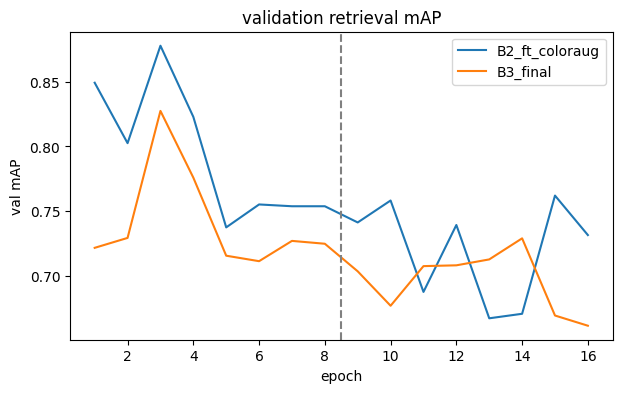

In [17]:
def ci_str(per: pd.DataFrame, col: str) -> str:
    if len(per) == 0:
        return "n/a"
    lo, hi = bootstrap_ci(per[col].to_numpy(), CFG.bootstrap)
    return f"[{lo:.2f},{hi:.2f}]"

def fmt(x):
    return "n/a" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{x:.3f}"

def summary_table(split: str) -> pd.DataFrame:
    rows = []
    for name, v in RUNS.items():
        r = v["res"][split]
        d, c = r["design"], r["cross"]
        va = r["verif_all"]; vs = r["verif_neg_samecolor"]
        probe = v["probe_" + split]
        rows.append({
            "model": name,
            "queries": d["n_queries"], "gallery": d.get("gallery"),
            "R@1": fmt(d.get("R@1")), "R@5": fmt(d.get("R@5")), "R@10": fmt(d.get("R@10")), "mAP": fmt(d.get("mAP")), "MRR": fmt(d.get("MRR")),
            "R@1 CI": ci_str(d["per_query"], "r1"),
            "xcolor queries": c["n_queries"], "xcolor R@1": fmt(c.get("R@1")), "xcolor R@5": fmt(c.get("R@5")), "xcolor mAP": fmt(c.get("mAP")),
            "+Kaggle R@1": fmt(r["design_plus_kaggle"].get("R@1")), "+Kaggle mAP": fmt(r["design_plus_kaggle"].get("mAP")),
            "verif pos/total": f"{va.get('pos', 0)}/{va.get('n', 0)}", "verif AUC": fmt(va.get("roc_auc")), "verif F1": fmt(va.get("f1")), "EER": fmt(va.get("eer")),
            "samecolor AUC": fmt(vs.get("roc_auc")), "samecolor F1": fmt(vs.get("f1")),
            "recolor inst R@1": fmt(probe.get("instance_R1")), "recolor design R@1": fmt(probe.get("design_R1")),
        })
    return pd.DataFrame(rows).set_index("model")

pd.set_option("display.width", 250, "display.max_columns", 40)
for s in ("val", "test"):
    print(f"\n=== {s.upper()} split | label source: {'manual verified' if LABELS_ARE_MANUAL else 'auto pseudo-labels (provisional)'} ===")
    print(summary_table(s).T)
r3 = RUNS[FINAL_NAME]["res"]["test"]
print("\nfinal model verification threshold (chosen on val only):", round(RUNS[FINAL_NAME]["res"]["threshold"], 4))
for key in ("verif_all", "verif_neg_samecolor", "verif_neg_random"):
    m = r3[key]
    print(key, {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m.items()})
for name, v in RUNS.items():
    if v["history"] is not None:
        v["history"].to_csv(WORK / "out" / f"history_{name}.csv", index=False)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for name in ("B2_ft_coloraug", "B3_final"):
    h = RUNS[name]["history"]
    ax.plot(h.epoch, h.val_mAP, label=name)
ax.axvline(CFG.stage0_epochs + 0.5, color="gray", ls="--")
ax.set_xlabel("epoch"); ax.set_ylabel("val mAP"); ax.legend(); ax.set_title("validation retrieval mAP")
fig.savefig(WORK / "figures" / "val_curve.png", dpi=120, bbox_inches="tight"); plt.show()

## 15. Hard-negative, color-invariance and error analysis

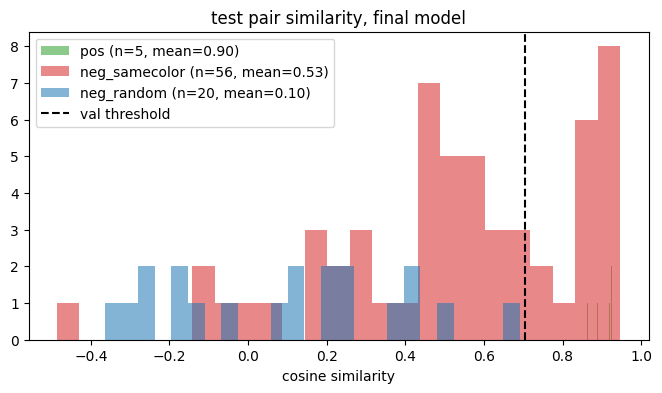

top-1 errors: 4 of 8 queries | mean color similarity of wrong top-1: 0.777 vs mean pairwise color similarity in test set: 0.221
B1_frozen_rgb: same-color negatives -> AUC 0.904, FP 14, TN 42
B4_frozen_gray: same-color negatives -> AUC 0.914, FP 11, TN 45
B2_ft_coloraug: same-color negatives -> AUC 0.857, FP 17, TN 39
B3_final: same-color negatives -> AUC 0.896, FP 17, TN 39


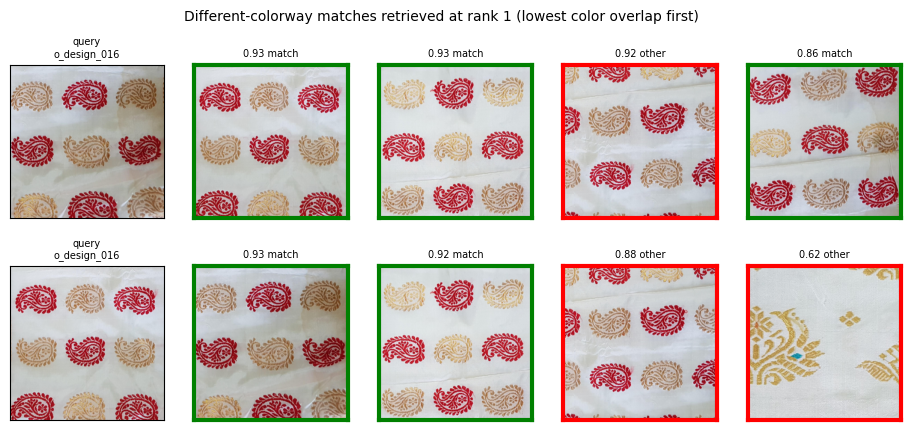

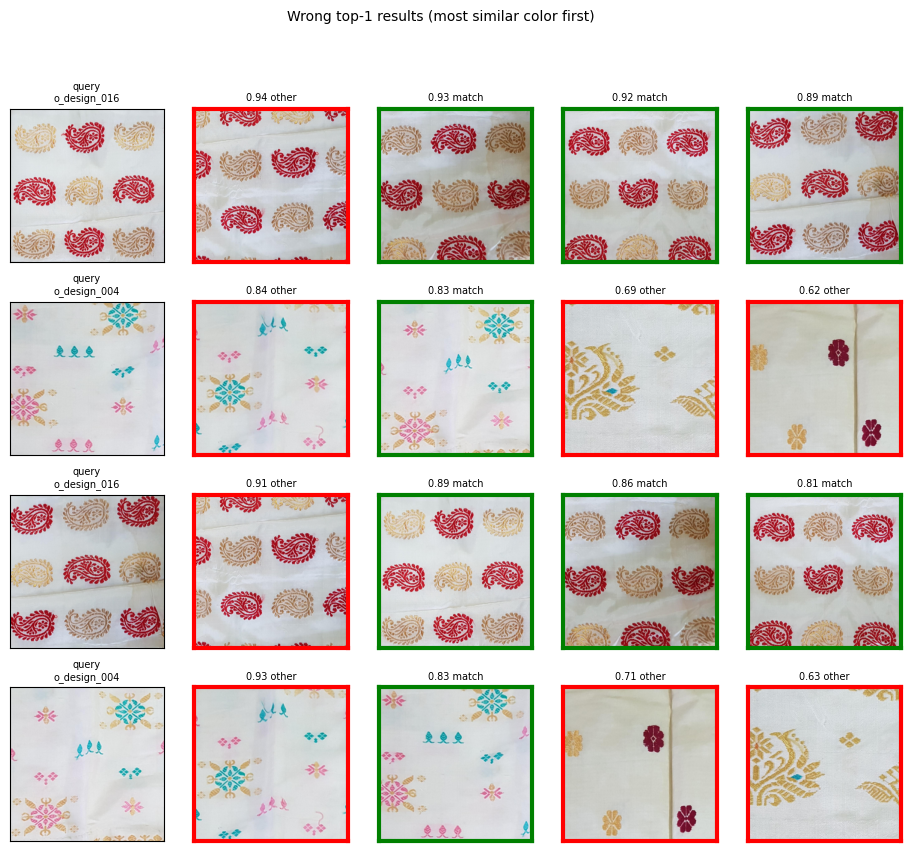

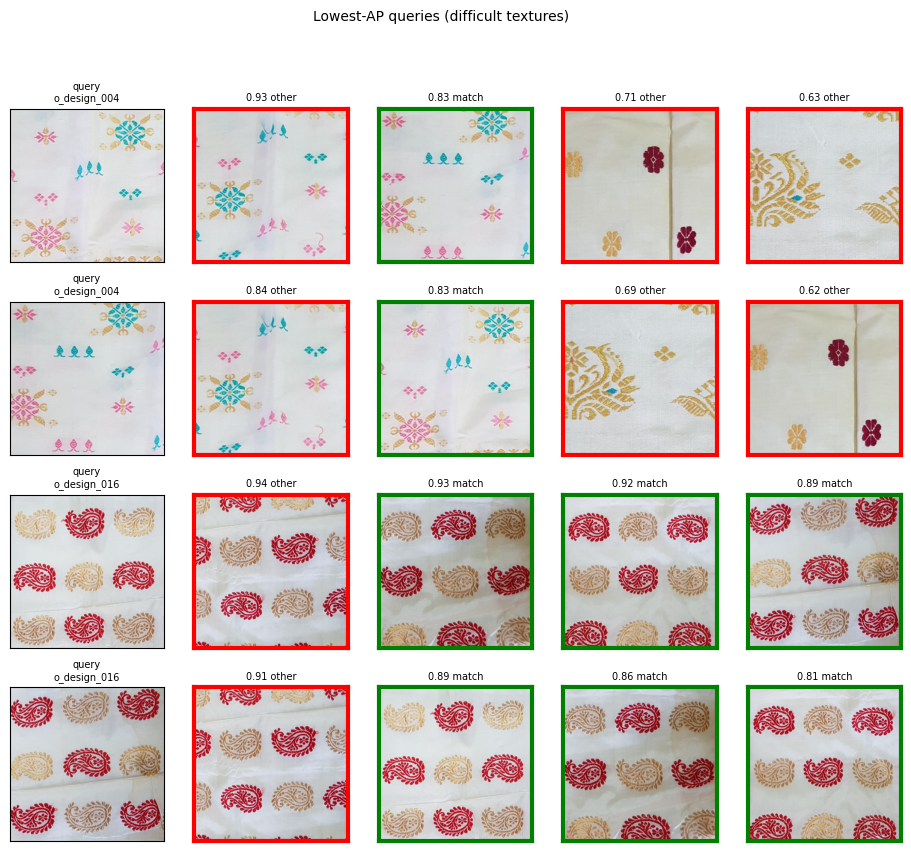

Low-texture queries: no rows to show
low-texture test queries: 0 | R@1 nan vs overall 0.500


In [18]:
pairs = r3["pairs"]
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for t, col in (("pos", "tab:green"), ("neg_samecolor", "tab:red"), ("neg_random", "tab:blue")):
    sc = pairs[pairs.type == t].score
    if len(sc):
        ax.hist(sc, bins=25, alpha=0.55, color=col, label=f"{t} (n={len(sc)}, mean={sc.mean():.2f})")
ax.axvline(RUNS[FINAL_NAME]["res"]["threshold"], color="k", ls="--", label="val threshold")
ax.set_xlabel("cosine similarity"); ax.legend(); ax.set_title("test pair similarity, final model")
fig.savefig(WORK / "figures" / "pair_similarity.png", dpi=120, bbox_inches="tight"); plt.show()

idx_t = split_idx("test")
pq = r3["design"]["per_query"]
if len(pq):
    wrong = pq[pq.first_hit > 0].copy()
    if len(wrong):
        wrong["top1"] = wrong.top.map(lambda t: t[0])
        wrong["color_sim_top1"] = [hist_intersection(COLSIG[idx_t[q]][None], COLSIG[idx_t[t]][None])[0, 0] for q, t in zip(wrong["query"], wrong.top1)]
        all_cs = hist_intersection(COLSIG[idx_t], COLSIG[idx_t])
        print(f"top-1 errors: {len(wrong)} of {len(pq)} queries | mean color similarity of wrong top-1: {wrong.color_sim_top1.mean():.3f} vs mean pairwise color similarity in test set: {all_cs[np.triu_indices(len(idx_t), 1)].mean():.3f}")
    else:
        print("no top-1 errors on test queries")
    for name in RUNS:
        p = RUNS[name]["res"]["test"]["verif_neg_samecolor"]
        print(f"{name}: same-color negatives -> AUC {fmt(p.get('roc_auc'))}, FP {p.get('FP')}, TN {p.get('TN')}")

def draw_grid(rows, title: str, fname: str, idx_map: np.ndarray, emb: np.ndarray, k: int = 4):
    if not rows or not CFG.save_image_grids:
        print(f"{title}: no rows to show")
        return
    fig, axes = plt.subplots(len(rows), k + 1, figsize=(2.3 * (k + 1), 2.4 * len(rows)), squeeze=False)
    for r, (q, tops) in enumerate(rows):
        gq = idx_map[q]
        axes[r, 0].imshow(IMGS[gq]); axes[r, 0].set_title(f"query\n{META.at[gq, 'design_id'][-12:]}", fontsize=7)
        for c in range(k):
            ax = axes[r, c + 1]
            if c < len(tops):
                gt = idx_map[tops[c]]
                same = META.at[gq, "design_id"] == META.at[gt, "design_id"]
                ax.imshow(IMGS[gt])
                ax.set_title(f"{float(emb[gq] @ emb[gt]):.2f} {'match' if same else 'other'}", fontsize=7)
                for sp in ax.spines.values():
                    sp.set_edgecolor("green" if same else "red"); sp.set_linewidth(3)
        for ax in axes[r]:
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title, fontsize=10)
    fig.savefig(WORK / "figures" / fname, dpi=110, bbox_inches="tight"); plt.show()

emb_f = RUNS[FINAL_NAME]["emb"]
cross_pq = r3["cross"]["per_query"]
if len(cross_pq):
    ok = cross_pq[cross_pq.first_hit == 0].copy()
    ok["cs"] = [hist_intersection(COLSIG[idx_t[q]][None], COLSIG[idx_t[t[0]]][None])[0, 0] for q, t in zip(ok["query"], ok.top)]
    ok = ok.sort_values("cs").head(4)
    draw_grid([(int(q), t) for q, t in zip(ok["query"], ok.top)], "Different-colorway matches retrieved at rank 1 (lowest color overlap first)", "grid_color_invariant_success.png", idx_t, emb_f)
if len(pq):
    bad = pq[pq.first_hit > 0].copy()
    if len(bad):
        bad["cs"] = [hist_intersection(COLSIG[idx_t[q]][None], COLSIG[idx_t[t[0]]][None])[0, 0] for q, t in zip(bad["query"], bad.top)]
        bad = bad.sort_values("cs", ascending=False).head(4)
        draw_grid([(int(q), t) for q, t in zip(bad["query"], bad.top)], "Wrong top-1 results (most similar color first)", "grid_samecolor_failures.png", idx_t, emb_f)
    hard = pq.sort_values("ap").head(4)
    draw_grid([(int(q), t) for q, t in zip(hard["query"], hard.top)], "Lowest-AP queries (difficult textures)", "grid_difficult.png", idx_t, emb_f)
    lt = pq[[bool(META.at[idx_t[q], "low_texture"]) for q in pq["query"]]]
    lt_bad = lt[lt.first_hit > 0].head(4) if (lt.first_hit > 0).any() else lt.head(4)
    draw_grid([(int(q), t) for q, t in zip(lt_bad["query"], lt_bad.top)], "Low-texture queries", "grid_low_texture.png", idx_t, emb_f)
    print(f"low-texture test queries: {len(lt)} | R@1 {lt.r1.mean() if len(lt) else float('nan'):.3f} vs overall {pq.r1.mean():.3f}")

## 16. Gallery and inference

In [19]:
@dataclass
class Gallery:
    emb: np.ndarray
    meta: pd.DataFrame

def build_gallery(model: nn.Module, meta: pd.DataFrame, imgs: np.ndarray = None) -> Gallery:
    imgs = IMGS if imgs is None else imgs
    emb = embed_images(model, imgs[meta.index.to_numpy()])
    cols = ["name", "design_id", "colorway_id", "category", "source", "label_source"]
    return Gallery(emb=emb, meta=meta[cols].reset_index(drop=True).copy())

def embed_image(model: nn.Module, image) -> np.ndarray:
    arr = load_rgb(Path(image), CFG.store_size) if isinstance(image, (str, Path)) else np.asarray(image)
    if arr.shape[0] != CFG.store_size or arr.shape[1] != CFG.store_size:
        arr = cv2.resize(arr, (CFG.store_size, CFG.store_size), interpolation=cv2.INTER_AREA)
    return embed_images(model, arr[None])[0]

def retrieve_top_k(query, gallery_embeddings: np.ndarray, gallery_metadata: pd.DataFrame, top_k: int = 5,
                   model: nn.Module = None, exclude_name: Optional[str] = None) -> pd.DataFrame:
    model = FINAL_MODEL if model is None else model
    q = embed_image(model, query)
    s = gallery_embeddings @ q
    order = np.argsort(-s)
    if exclude_name is not None:
        order = order[gallery_metadata.name.to_numpy()[order] != exclude_name]
    order = order[:top_k]
    out = gallery_metadata.iloc[order].copy()
    out.insert(0, "rank", np.arange(1, len(order) + 1))
    out.insert(2, "similarity", s[order].round(4))
    return out.reset_index(drop=True)

def verify_pair(image_a, image_b, threshold: float, model: nn.Module = None) -> Dict:
    model = FINAL_MODEL if model is None else model
    sim = float(embed_image(model, image_a) @ embed_image(model, image_b))
    return dict(similarity=round(sim, 4), prediction="same design" if sim >= threshold else "different design", threshold=round(float(threshold), 4))

FINAL_THRESHOLD = RUNS[FINAL_NAME]["res"]["threshold"]
GAL_META = META[(META.source == "deeplure") & META.usable]
GALLERY = build_gallery(FINAL_MODEL, GAL_META)
print("gallery:", GALLERY.emb.shape, "| designs:", GALLERY.meta.design_id.nunique())

demo_q = idx_t[0] if len(idx_t) else GAL_META.index[0]
demo = retrieve_top_k(IMGS[demo_q], GALLERY.emb, GALLERY.meta, top_k=5, exclude_name=META.at[demo_q, "name"])
print("query:", META.at[demo_q, "name"], "| design:", META.at[demo_q, "design_id"])
print(demo.to_string(index=False))
a, b = idx_t[0], idx_t[min(1, len(idx_t) - 1)]
print("verify:", verify_pair(IMGS[a], IMGS[b], FINAL_THRESHOLD))

gallery: (160, 256) | designs: 106
query: img_187840.jpg | design: auto_design_074
 rank           name  similarity       design_id         colorway_id category   source  label_source
    1 img_590289.jpg      0.8983 auto_design_035 auto_design_035_cw0          deeplure auto_proposed
    2 img_519993.jpg      0.6934 auto_design_081 auto_design_081_cw0          deeplure auto_proposed
    3 img_586052.jpg      0.6639 auto_design_102 auto_design_102_cw0          deeplure auto_proposed
    4 img_529952.jpg      0.6588 auto_design_000 auto_design_000_cw0          deeplure auto_proposed
    5 img_386972.jpg      0.6403 auto_design_088 auto_design_088_cw0          deeplure auto_proposed
verify: {'similarity': 0.1788, 'prediction': 'different design', 'threshold': 0.7034}


## 17. Efficiency report

In [20]:
def efficiency_report(model: SareeEmbedder) -> Dict:
    model.eval()
    total = sum(p.numel() for p in model.parameters())
    trainable_final = sum(p.numel() for p in model.backbone.encoder.layer[-CFG.unfreeze_blocks:].parameters()) + sum(p.numel() for p in model.head.parameters())
    size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    x1 = torch.randn(1, 3, CFG.img_size, CFG.img_size, device=DEVICE)
    xb = torch.randn(64, 3, CFG.img_size, CFG.img_size, device=DEVICE)
    def timeit(x, reps):
        with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_AMP):
            for _ in range(5):
                model(x)
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            t = time.time()
            for _ in range(reps):
                model(x)
            if DEVICE == "cuda":
                torch.cuda.synchronize()
        return (time.time() - t) / reps
    lat1 = timeit(x1, 30)
    latb = timeit(xb, 5)
    flops = None
    try:
        from torch.utils.flop_counter import FlopCounterMode
        with FlopCounterMode(display=False) as fc, torch.no_grad():
            model(x1)
        flops = fc.get_total_flops()
    except Exception:
        pass
    return dict(total_params_M=total / 1e6, tuned_params_M_final_stage=trainable_final / 1e6, embedding_dim=CFG.emb_dim,
                model_size_MB_fp32=size_mb, latency_ms_batch1=lat1 * 1e3, images_per_sec_batch64=64 / latb,
                GFLOPs_per_image=None if flops is None else flops / 1e9, device=DEVICE, precision="fp16 autocast" if USE_AMP else "fp32",
                gallery_search_cost="1 x %d-d dot product per gallery image" % CFG.emb_dim)

EFF = efficiency_report(FINAL_MODEL)
for k, v in EFF.items():
    print(f"{k}: {round(v, 3) if isinstance(v, float) else v}")

total_params_M: 23.109
tuned_params_M_final_stage: 8.152
embedding_dim: 256
model_size_MB_fp32: 92.436
latency_ms_batch1: 10.038
images_per_sec_batch64: 772.701
GFLOPs_per_image: 12.249
device: cuda
precision: fp16 autocast
gallery_search_cost: 1 x 256-d dot product per gallery image


## 18. Export

In [21]:
APPROACH_NOTE = ("DINOv2-S/14 backbone (frozen warm-up, then last 4 blocks at LR 1e-5) + MLP head -> 256-d L2-normalised embedding, cosine retrieval. "
                 "Two-view supervised contrastive loss (T=0.1) with GPU hue/channel-permutation/saturation/gamma/grayscale colour augmentation; "
                 "batches pair same-colour different-design hard negatives, with a pHash/similarity false-negative mask; de-duplicated Kaggle images act as extra negatives. "
                 "Design-disjoint splits; verification threshold chosen on validation only.")
print(len(APPROACH_NOTE), "characters")
(WORK / "out" / "approach_note.txt").write_text(APPROACH_NOTE)

def to_jsonable(o):
    if isinstance(o, dict):
        return {k: to_jsonable(v) for k, v in o.items() if k not in ("per_query", "pairs")}
    if isinstance(o, (np.floating, float)):
        return float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    return o

summary = dict(label_source="manual_verified" if LABELS_ARE_MANUAL else "auto_proposed_pseudo_labels", config=asdict(CFG),
               results={n: dict(val=to_jsonable(v["res"]["val"]), test=to_jsonable(v["res"]["test"]), threshold=v["res"]["threshold"],
                                recolor_probe_val=v["probe_val"], recolor_probe_test=v["probe_test"]) for n, v in RUNS.items()},
               efficiency=EFF, final_model=FINAL_NAME, final_threshold=FINAL_THRESHOLD,
               pretrained_resources=[CFG.backbone + " (Meta DINOv2, HuggingFace)", "Kaggle Indian Saree Patterns (Roboflow export, MIT) as de-duplicated auxiliary negatives"])
(WORK / "out" / "results.json").write_text(json.dumps(summary, indent=1, default=str))
for s in ("val", "test"):
    summary_table(s).to_csv(WORK / "out" / f"results_{s}.csv")

CKPT = WORK / "out" / "saree_design_embedder.pt"
torch.save(dict(config=asdict(CFG), backbone=CFG.backbone, state_dict={k: v.cpu() for k, v in FINAL_MODEL.state_dict().items()},
                threshold=FINAL_THRESHOLD, gallery_embeddings=GALLERY.emb, gallery_meta=GALLERY.meta.to_dict("list"),
                label_source=summary["label_source"], approach_note=APPROACH_NOTE), CKPT)
print("checkpoint:", CKPT, f"{CKPT.stat().st_size / 1e6:.1f} MB")

def load_embedder(path: str):
    ck = torch.load(path, map_location="cpu", weights_only=False)
    bb = AutoModel.from_pretrained(ck["backbone"])
    c = ck["config"]
    m = SareeEmbedder(bb, c["emb_dim"], c["head_hidden"], c["head_dropout"])
    m.load_state_dict(ck["state_dict"])
    return m.to(DEVICE).eval(), ck

chk_model, chk = load_embedder(str(CKPT))
probe_emb = embed_images(chk_model, IMGS[:8])
assert np.allclose(probe_emb, embed_images(FINAL_MODEL, IMGS[:8]), atol=1e-3), "reload mismatch"
print("reload check passed")

bundle = shutil.make_archive(str(WORK / "results_bundle"), "zip", WORK, "out")
figs = shutil.make_archive(str(WORK / "figures_bundle"), "zip", WORK, "figures")
print("bundles:", bundle, figs)
if IN_COLAB:
    colab_files.download(str(CKPT))
    colab_files.download(bundle)
    colab_files.download(figs)

486 characters
checkpoint: /content/saree_work/out/saree_design_embedder.pt 92.8 MB


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

reload check passed
bundles: /content/saree_work/results_bundle.zip /content/saree_work/figures_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>